项目任务  
数据可视化：绘制散点图，观察学习时间与成绩的关系  
线性回归尝试：用一次多项式（degree=1）拟合，观察效果  
多项式回归：用2次、3次、4次多项式分别拟合  
模型比较：计算不同模型的MSE（均方误差），可视化拟合曲线  
过拟合实验：尝试5次、6次多项式，观察过拟合现象  
涉及的知识点  
模型评估：均方误差（MSE）、R²分数  
过拟合与欠拟合：观察不同阶数下的拟合效果  
数据标准化（可选）：了解多项式回归中标准化的作用  
进阶挑战（可选）  
使用交叉验证选择最佳的多项式阶数  
添加正则化（岭回归）防止过拟合  

开始梯度下降优化...
初始参数: b=0.0000, w=[0. 0. 0. 0.]
初始损失: 409.389167
第  100 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000950
第  200 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000902
第  300 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000857
第  400 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000815
第  500 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000774
第  600 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000735
第  700 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000698
第  800 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000663
第  900 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000630
第 1000 步: 损失 = 737787963051011333964941773242368.000000, 学习率 = 0.000599

优化完成!
最终参数: b = -1757.7764
最终权重: w = [-18268.785635, -195012.564705, 335542195460.260437, 3271533618106.539062]
最终损失: 737787963051011333964941773242368.00000000

最终的预测函数：
y = -1757.7764 -18268.7856*x -195012.5647*x^2 +

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_33388\1784570944.py:163: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
d:\Anaconda\envs\pytorch\lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


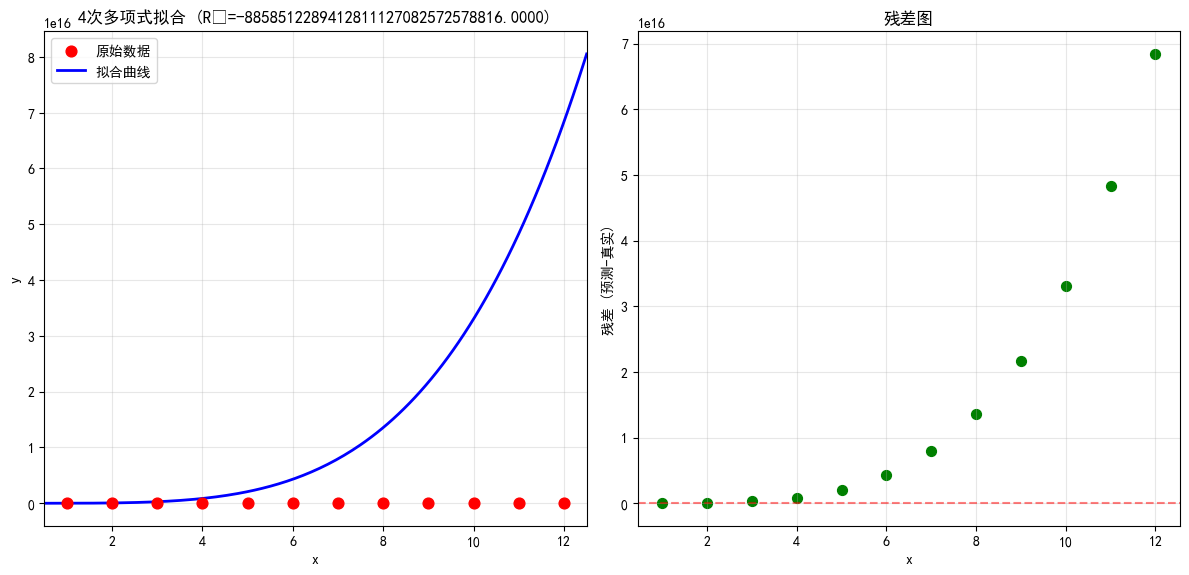


预测结果对比:
   x      真实y      预测y       残差
   1     1.90 3607075598527.67 3607075598525.77
   2     8.70 55028874635041.10 55028874635032.40
   3     6.70 274053860532379.47 274053860532372.78
   4    21.70 858987303549696.75 858987303549675.00
   5    21.60 2086651280780703.75 2086651280780682.25
   6    29.60 4312384676153667.50 4312384676153638.00
   7    30.00 7970043180431414.00 7970043180431384.00
   8    28.00 13571999291211324.00 13571999291211296.00
   9    21.10 21709142312925340.00 21709142312925320.00
  10    23.70 33050878356839952.00 33050878356839928.00
  11    13.10 48345130341056208.00 48345130341056192.00
  12    10.60 68418337990509728.00 68418337990509720.00


In [25]:
import numpy as np  

def nth_degree_polynomial(x, b, w):
    """
    计算 1 元 N 次多项式：y = b + w[0]*x + w[1]*x^2 + ... + w[N-1]*x^N
    """ 
    degree = len(w)
    y_hat = np.zeros_like(x, dtype=float)
    
    for i in range(degree):
        y_hat += w[i] * (x ** (i + 1))
    
    y_hat += b
    return y_hat

def loss_function(x, b, w, y, regularization=0.0):  
    """
    计算损失函数（均方差损失 + L2正则化）
    """
    y_hat = nth_degree_polynomial(x, b, w)
    mse = np.mean((y_hat - y) ** 2)
    reg_term = regularization * np.sum(w**2)  # L2正则化项
    return mse + reg_term

def gradient_descent(x, b, w, y, regularization, steps, alpha):  
    """
    使用数值微分的梯度下降优化
    """
    print(f"开始梯度下降优化...")
    print(f"初始参数: b={b:.4f}, w={w}")
    print(f"初始损失: {loss_function(x, b, w, y, regularization):.6f}")
    
    delta = 1e-7  # 数值微分的微小增量
    
    for i in range(steps):
        # ===== 计算b的梯度 =====
        # 计算损失函数在b处的数值梯度
        loss_b_plus = loss_function(x, b + delta, w, y, regularization)
        loss_b = loss_function(x, b, w, y, regularization)
        dL_db = (loss_b_plus - loss_b) / delta
        
        # ===== 计算w的梯度 =====
        dL_dw = np.zeros_like(w)
        for j in range(len(w)):
            # 创建w的副本，只修改第j个元素
            w_plus = w.copy()
            w_plus[j] = w[j] + delta
            
            # 计算损失函数在w[j]处的数值梯度
            loss_w_plus = loss_function(x, b, w_plus, y, regularization)
            loss_w = loss_function(x, b, w, y, regularization)
            dL_dw[j] = (loss_w_plus - loss_w) / delta
        
        # ===== 更新参数 =====
        w -= alpha * dL_dw
        b -= alpha * dL_db
        
        # 每100步显示进度
        if (i + 1) % 100 == 0:
            current_loss = loss_function(x, b, w, y, regularization)
            alpha *= 0.95  # 学习率衰减
            print(f"第 {i+1:4d} 步: 损失 = {current_loss:.6f}, "
                  f"学习率 = {alpha:.6f}")
    
    return b, w

def format_polynomial(b, w):
    """格式化多项式为可读字符串"""
    terms = []
    
    # 处理常数项b
    if abs(b) > 1e-10:
        terms.append(f"{b:+.4f}")
    else:
        terms.append("0.0000")
    
    # 处理各次项
    for i, weight in enumerate(w):
        power = i + 1
        if abs(weight) > 1e-10:  # 只显示非零项
            if power == 1:
                terms.append(f"{weight:+.4f}*x")
            else:
                terms.append(f"{weight:+.4f}*x^{power}")
    
    # 构建最终字符串
    expression = "y = " + terms[0]
    for term in terms[1:]:
        if term[0] != '-':  # 正数项前加+
            expression += " + " + term
        else:  # 负数项前加空格
            expression += " " + term
    
    return expression

# 测试数据
x = np.arange(1, 13, dtype=float)
y = np.array([1.9, 8.7, 6.7, 21.7, 21.6, 29.6, 30.0, 28.0, 21.1, 23.7, 13.1, 10.6], dtype=float)

# 初始化参数
b = 0.0  # 初始偏置
degree = 4  # 4次多项式
w = np.zeros(degree, dtype=float)  # 初始权重

# 运行梯度下降
regularization = 0.01  # 正则化系数
steps = 1000  # 迭代次数
alpha = 0.001  # 学习率

b_opt, w_opt = gradient_descent(x, b, w, y, regularization, steps, alpha)

print(f"\n" + "="*50)
print(f"优化完成!")
print(f"最终参数: b = {b_opt:.4f}")
print(f"最终权重: w = [{', '.join(f'{w:.6f}' for w in w_opt)}]")
print(f"最终损失: {loss_function(x, b_opt, w_opt, y, regularization):.8f}")

print(f"\n最终的预测函数：")
print(format_polynomial(b_opt, w_opt))

# 计算R²分数
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

y_pred = nth_degree_polynomial(x, b_opt, w_opt)
r2 = r2_score(y, y_pred)
print(f"\nR²分数: {r2:.6f}")

# 可视化验证
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'SimHei'

# 生成预测曲线
x_plot = np.linspace(0.5, 12.5, 200)
y_plot = nth_degree_polynomial(x_plot, b_opt, w_opt)

plt.figure(figsize=(12, 6))

# 子图1：拟合曲线
plt.subplot(1, 2, 1)
plt.scatter(x, y, color='red', label='原始数据', s=60, zorder=5)
plt.plot(x_plot, y_plot, 'b-', label='拟合曲线', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'4次多项式拟合 (R²={r2:.4f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 12.5)

# 子图2：残差图
plt.subplot(1, 2, 2)
residuals = y_pred - y
plt.scatter(x, residuals, color='green', s=50)
plt.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('残差 (预测-真实)')
plt.title('残差图')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 显示预测值与真实值对比
print(f"\n预测结果对比:")
print(f"{'x':>4} {'真实y':>8} {'预测y':>8} {'残差':>8}")
for i in range(len(x)):
    error = y_pred[i] - y[i]
    print(f"{x[i]:4.0f} {y[i]:8.2f} {y_pred[i]:8.2f} {error:8.2f}")

数据标准化完成:
x均值=6.50, x标准差=3.45
y均值=18.06, y标准差=9.13
开始梯度下降优化...
初始参数: b=0.0000, w=[-0.16293306  0.05058119  0.02783851  0.07189771 -0.06680129]
初始损失: 0.827554

优化完成!（在标准化数据上）
最终参数: b = -0.119925
最终权重: w = [-1.742931, -0.075412, 0.117107, 0.109534, 0.223869]
最终损失: 0.06702573

标准化尺度下的预测函数：
y = -0.1199 -1.7429*x -0.0754*x^2 + +0.1171*x^3 + +0.1095*x^4 + +0.2239*x^5

原始尺度R²分数: 0.932974


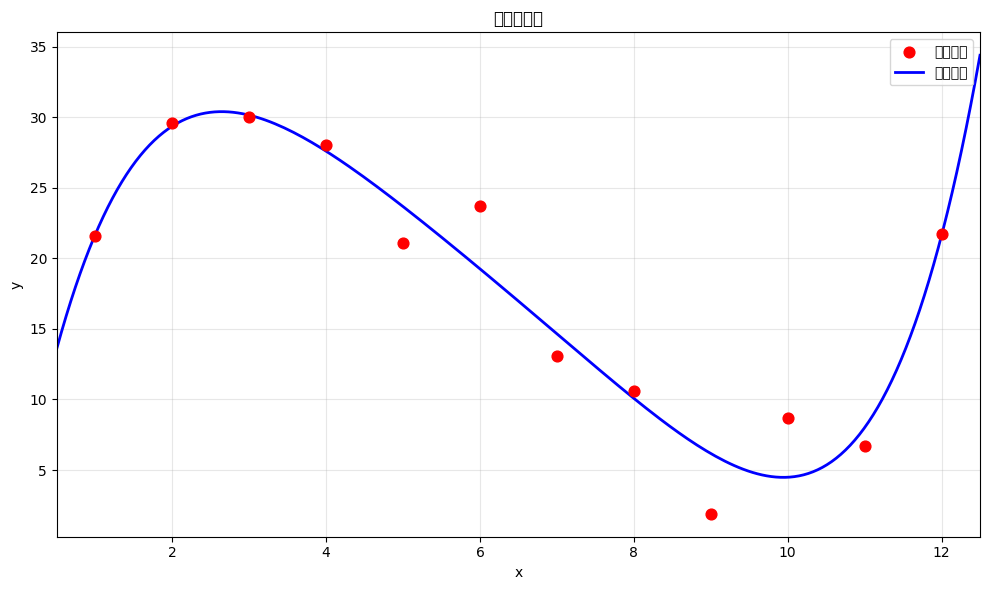


预测结果对比:
   x      真实值        预测值         残差
----------------------------------------
   1    21.60      21.70       0.10
   2    29.60      29.36      -0.24
   3    30.00      30.14       0.14
   4    28.00      27.58      -0.42
   5    21.10      23.66       2.56
   6    23.70      19.25      -4.45
   7    13.10      14.65       1.55
   8    10.60      10.08      -0.52
   9     1.90       6.17       4.27
  10     8.70       4.49      -4.21
  11     6.70       8.00       1.30
  12    21.70      21.61      -0.09

模型评估:
R²分数: 0.9330
平均绝对误差: 1.6546
均方根误差: 2.3627


In [1]:
import numpy as np  
import warnings
warnings.filterwarnings('ignore')  # 忽略字体警告

def nth_degree_polynomial(x, b, w):
    """计算 1 元 N 次多项式"""
    degree = len(w)
    y_hat = np.zeros_like(x, dtype=float)
    
    for i in range(degree):
        y_hat += w[i] * (x ** (i + 1))
    
    y_hat += b
    return y_hat

def loss_function(x, b, w, y, regularization=0.0):  
    """计算损失函数（均方差损失 + L2正则化）"""
    y_hat = nth_degree_polynomial(x, b, w)
    mse = np.mean((y_hat - y) ** 2)
    reg_term = regularization * np.sum(w**2)
    return mse + reg_term

def gradient_descent(x, b, w, y, regularization, steps, alpha):  
    """使用数值微分的梯度下降优化（带梯度裁剪）"""
    print(f"开始梯度下降优化...")
    print(f"初始参数: b={b:.4f}, w={w}")
    print(f"初始损失: {loss_function(x, b, w, y, regularization):.6f}")
    
    delta = 1e-7
    grad_clip = 10.0
    loss_history = []
    
    for i in range(steps):
        # 计算b的梯度
        loss_b_plus = loss_function(x, b + delta, w, y, regularization)
        loss_b = loss_function(x, b, w, y, regularization)
        dL_db = (loss_b_plus - loss_b) / delta
        
        # 计算w的梯度
        dL_dw = np.zeros_like(w)
        for j in range(len(w)):
            w_plus = w.copy()
            w_plus[j] = w[j] + delta
            
            loss_w_plus = loss_function(x, b, w_plus, y, regularization)
            loss_w = loss_function(x, b, w, y, regularization)
            dL_dw[j] = (loss_w_plus - loss_w) / delta
        
        # 梯度裁剪
        dL_db = np.clip(dL_db, -grad_clip, grad_clip)
        dL_dw = np.clip(dL_dw, -grad_clip, grad_clip)
        
        # 更新参数
        w -= alpha * dL_dw
        b -= alpha * dL_db
        
        # if (i + 1) % 100 == 0:
        #     current_loss = loss_function(x, b, w, y, regularization)
        #     loss_history.append(current_loss)
        #     if (i + 1) % 500 == 0:  # 减少输出频率
        #         print(f"第 {i+1:4d} 步: 损失 = {current_loss:.6f}")
    
    return b, w, loss_history

def format_polynomial(b, w):
    """格式化多项式为可读字符串"""
    terms = []
    
    if abs(b) > 1e-10:
        terms.append(f"{b:+.4f}")
    
    for i, weight in enumerate(w):
        power = i + 1
        if abs(weight) > 1e-10:
            if power == 1:
                terms.append(f"{weight:+.4f}*x")
            else:
                terms.append(f"{weight:+.4f}*x^{power}")
    
    if not terms:
        return "y = 0"
    
    expression = "y = " + terms[0]
    for term in terms[1:]:
        if term[0] != '-':
            expression += " + " + term
        else:
            expression += " " + term
    
    return expression

# ===== 数据标准化 =======
# ======================================================================================================================

def standardize_data(x, y):
    """标准化数据"""
    x_mean = np.mean(x)
    x_std = np.std(x)
    x_scaled = (x - x_mean) / x_std
    
    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = (y - y_mean) / y_std
    
    return x_scaled, y_scaled, (x_mean, x_std, y_mean, y_std)

# 原始测试数据
x_orig = np.arange(1, 13, dtype=float)
y_orig = np.array([21.6, 29.6, 30.0, 28.0, 21.1, 23.7, 13.1, 10.6, 1.9, 8.7, 6.7, 21.7,], dtype=float)

# 数据标准化
x_scaled, y_scaled, scaling_params = standardize_data(x_orig, y_orig)
print(f"数据标准化完成:")
print(f"x均值={scaling_params[0]:.2f}, x标准差={scaling_params[1]:.2f}")
print(f"y均值={scaling_params[2]:.2f}, y标准差={scaling_params[3]:.2f}")

# 初始化参数
degree = int(input("多项式维度"))   # 指定多项式维度
b = 0.0
w = np.random.normal(0, 0.1, degree)

# ======================================================================================================================
# ======================================================================================================================

# 运行梯度下降
regularization = 0.0
steps = 5000  # 增加迭代次数
alpha = 0.01

b_opt, w_opt, loss_history = gradient_descent(x_scaled, b, w, y_scaled, regularization, steps, alpha)

print(f"\n" + "="*50)
print(f"优化完成!（在标准化数据上）")
print(f"最终参数: b = {b_opt:.6f}")
print(f"最终权重: w = [{', '.join(f'{w:.6f}' for w in w_opt)}]")
print(f"最终损失: {loss_function(x_scaled, b_opt, w_opt, y_scaled, regularization):.8f}")

print(f"\n标准化尺度下的预测函数：")
print(format_polynomial(b_opt, w_opt))

# 预测函数
def predict_original(x, b, w, scaling_params):
    """预测原始尺度的y值"""
    x_mean, x_std, y_mean, y_std = scaling_params
    x_scaled = (x - x_mean) / x_std
    y_scaled = nth_degree_polynomial(x_scaled, b, w)
    return y_scaled * y_std + y_mean

# 计算预测
y_pred_orig = predict_original(x_orig, b_opt, w_opt, scaling_params)

# 计算R²分数
def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

r2 = r2_score(y_orig, y_pred_orig)
print(f"\n原始尺度R²分数: {r2:.6f}")

# ===== 可视化（只保留第一个子图）=========
# ======================================================================================================================

import matplotlib.pyplot as plt

# 设置字体
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 创建单个图表（只显示拟合曲线）
plt.figure(figsize=(10, 6))

# 生成平滑的预测曲线
x_plot = np.linspace(0.5, 12.5, 200)
y_plot = predict_original(x_plot, b_opt, w_opt, scaling_params)

# 绘制原始数据点
plt.scatter(x_orig, y_orig, color='red', label='原始数据', s=60, zorder=5)

# 绘制拟合曲线
plt.plot(x_plot, y_plot, 'b-', label='拟合曲线', linewidth=2)

# 设置图表属性
plt.xlabel('x')
plt.ylabel('y')
plt.title('多项式拟合')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 12.5)

plt.tight_layout()
plt.show()

# 显示详细结果
print(f"\n预测结果对比:")
print(f"{'x':>4} {'真实值':>8} {'预测值':>10} {'残差':>10}")
print("-" * 40)
for i in range(len(x_orig)):
    error = y_pred_orig[i] - y_orig[i]
    print(f"{x_orig[i]:4.0f} {y_orig[i]:8.2f} {y_pred_orig[i]:10.2f} {error:10.2f}")

print(f"\n模型评估:")
print(f"R²分数: {r2:.4f}")
print(f"平均绝对误差: {np.mean(np.abs(y_pred_orig - y_orig)):.4f}")
print(f"均方根误差: {np.sqrt(np.mean((y_pred_orig - y_orig)**2)):.4f}")


### 对于多项式回归，我们没有必要使用梯度下降，可以从数学上得到其解析解

数据标准化完成:
x均值=6.50, x标准差=3.45
y均值=18.06, y标准差=9.13

直接计算多项式回归最优解
最优参数:
b = 4.490915
w = [24.324949, -8.059500, 1.181501, -0.092512, 0.003064]

多项式表达式:
y = +4.4909 + +24.3249*x -8.0595*x^2 + +1.1815*x^3 -0.0925*x^4 + +0.0031*x^5

R²分数: 0.933920


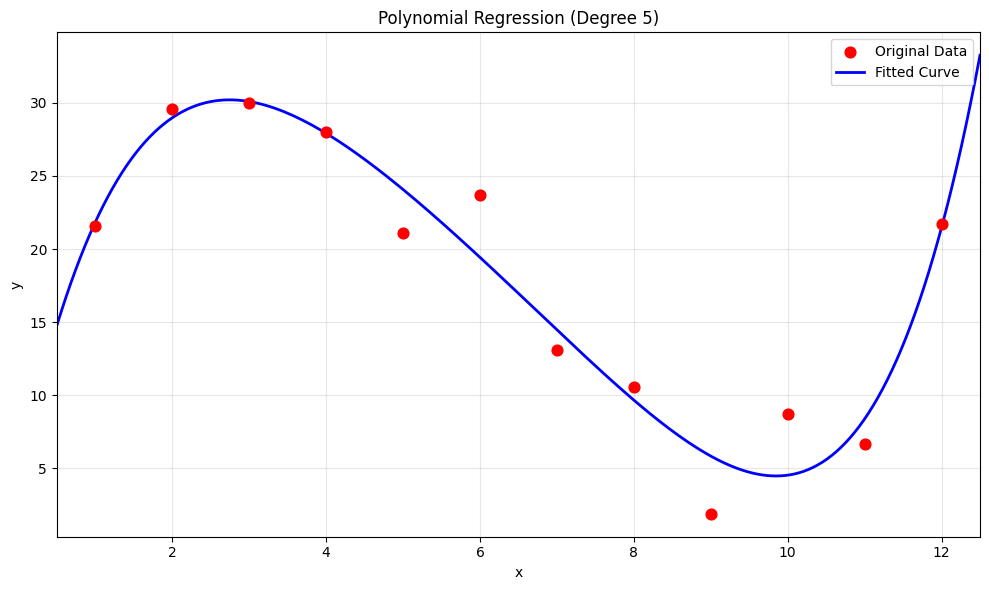


预测结果对比:
   x      真实值        预测值         残差
----------------------------------------
   1    21.60      21.85       0.25
   2    29.60      28.97      -0.63
   3    30.00      30.08       0.08
   4    28.00      27.91      -0.09
   5    21.10      24.07       2.97
   6    23.70      19.43      -4.27
   7    13.10      14.47       1.37
   8    10.60       9.67      -0.93
   9     1.90       5.85       3.95
  10     8.70       4.54      -4.16
  11     6.70       8.39       1.69
  12    21.70      21.47      -0.23

模型评估:
R²分数: 0.9339
平均绝对误差: 1.7176
均方根误差: 2.3460


In [2]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')

def polynomial_fit_direct(x, y, degree):
    """
    使用正规方程直接计算多项式回归的最优解
    
    参数:
        x: 自变量
        y: 因变量
        degree: 多项式阶数
    
    返回:
        b: 截距
        w: 权重系数
    """
    # 构建设计矩阵
    X = np.zeros((len(x), degree + 1))
    X[:, 0] = 1  # 截距项
    for i in range(1, degree + 1):
        X[:, i] = x ** i
    
    # 使用正规方程求解: θ = (X^T X)^(-1) X^T y
    # 添加正则化项以提高数值稳定性
    lambda_reg = 1e-8
    XTX = X.T @ X + lambda_reg * np.eye(degree + 1)
    XTy = X.T @ y
    
    # 求解线性方程组
    theta = np.linalg.solve(XTX, XTy)
    
    # 分离截距和权重
    b = theta[0]
    w = theta[1:]
    
    return b, w


def nth_degree_polynomial(x, b, w):
    """计算 1 元 N 次多项式"""
    degree = len(w)
    y_hat = np.zeros_like(x, dtype=float)
    
    for i in range(degree):
        y_hat += w[i] * (x ** (i + 1))
    
    y_hat += b
    return y_hat


def standardize_data(x, y):
    """标准化数据"""
    x_mean = np.mean(x)
    x_std = np.std(x)
    x_scaled = (x - x_mean) / x_std
    
    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = (y - y_mean) / y_std
    
    return x_scaled, y_scaled, (x_mean, x_std, y_mean, y_std)


def format_polynomial(b, w):
    """格式化多项式为可读字符串"""
    terms = []
    
    if abs(b) > 1e-10:
        terms.append(f"{b:+.4f}")
    
    for i, weight in enumerate(w):
        power = i + 1
        if abs(weight) > 1e-10:
            if power == 1:
                terms.append(f"{weight:+.4f}*x")
            else:
                terms.append(f"{weight:+.4f}*x^{power}")
    
    if not terms:
        return "y = 0"
    
    expression = "y = " + terms[0]
    for term in terms[1:]:
        if term[0] != '-':
            expression += " + " + term
        else:
            expression += " " + term
    
    return expression


def predict_original(x, b, w, scaling_params):
    """预测原始尺度的y值"""
    x_mean, x_std, y_mean, y_std = scaling_params
    x_scaled = (x - x_mean) / x_std
    y_scaled = nth_degree_polynomial(x_scaled, b, w)
    return y_scaled * y_std + y_mean


def r2_score(y_true, y_pred):
    """计算R²分数"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


# ===== 主程序 =====
# 原始测试数据
x_orig = np.arange(1, 13, dtype=float)
y_orig = np.array([21.6, 29.6, 30.0, 28.0, 21.1, 23.7, 13.1, 10.6, 1.9, 8.7, 6.7, 21.7], dtype=float)

# 数据标准化
x_scaled, y_scaled, scaling_params = standardize_data(x_orig, y_orig)
print("数据标准化完成:")
print(f"x均值={scaling_params[0]:.2f}, x标准差={scaling_params[1]:.2f}")
print(f"y均值={scaling_params[2]:.2f}, y标准差={scaling_params[3]:.2f}")

# 指定多项式维度
degree = 5  # 可以修改这个值

# 直接计算最优解
print("\n" + "="*50)
print("直接计算多项式回归最优解")
print("="*50)
b_opt, w_opt = polynomial_fit_direct(x_orig, y_orig, degree)

print(f"最优参数:")
print(f"b = {b_opt:.6f}")
print(f"w = [{', '.join(f'{w:.6f}' for w in w_opt)}]")
print(f"\n多项式表达式:")
print(format_polynomial(b_opt, w_opt))

# 计算预测值
y_pred_orig = nth_degree_polynomial(x_orig, b_opt, w_opt)

# 计算R²分数
r2 = r2_score(y_orig, y_pred_orig)
print(f"\nR²分数: {r2:.6f}")

# ===== 可视化 =====
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(10, 6))

# 生成平滑的预测曲线
x_plot = np.linspace(0.5, 12.5, 200)
y_plot = nth_degree_polynomial(x_plot, b_opt, w_opt)

# 绘制原始数据点
plt.scatter(x_orig, y_orig, color='red', label='Original Data', s=60, zorder=5)

# 绘制拟合曲线
plt.plot(x_plot, y_plot, 'b-', label='Fitted Curve', linewidth=2)

plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Polynomial Regression (Degree {degree})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0.5, 12.5)

plt.tight_layout()
plt.show()

# 显示详细结果
print(f"\n预测结果对比:")
print(f"{'x':>4} {'真实值':>8} {'预测值':>10} {'残差':>10}")
print("-" * 40)
for i in range(len(x_orig)):
    error = y_pred_orig[i] - y_orig[i]
    print(f"{x_orig[i]:4.0f} {y_orig[i]:8.2f} {y_pred_orig[i]:10.2f} {error:10.2f}")

print(f"\n模型评估:")
print(f"R²分数: {r2:.4f}")
print(f"平均绝对误差: {np.mean(np.abs(y_pred_orig - y_orig)):.4f}")
print(f"均方根误差: {np.sqrt(np.mean((y_pred_orig - y_orig)**2)):.4f}")